# results_figures — Tablas y figuras finales del proyecto

Notebook generado en Sub-paso 3.4 de Fase 3 del refactor. Su única fuente de
verdad es ``models_v2_results.csv``. Cero re-entrenamiento, cero re-ejecución
de los notebooks v2, cero llamadas a modelos.

**Salidas:**

- 5 tablas en ``reports/results/`` (T1–T5)
- 4 figuras obligatorias en ``reports/figures/`` (F1–F4)
- 2 figuras opcionales (F5–F6) — incluidas porque los criterios documentados
  en ``PHASE_3_4_RESULTS_FIGURES_PLAN.md`` §2 se cumplen.

**Política:** todas las referencias a nombres de modelos son dinámicas
(``df['model'].unique()``) — el source del notebook NO contiene literales de
clases de modelos para mantener la auditoría limpia.


## 1. Imports y configuración

In [1]:
# Resolver raíz del repo de forma robusta independiente del CWD.
# Funciona tanto si el notebook se ejecuta desde la raíz como desde notebooks/.
import sys
from pathlib import Path

_here = Path.cwd()
if (_here / 'environment.yml').exists() and (_here / 'src').exists():
    REPO_ROOT = _here
elif (_here.parent / 'environment.yml').exists() and (_here.parent / 'src').exists():
    REPO_ROOT = _here.parent
else:
    raise RuntimeError(
        f'No se pudo resolver REPO_ROOT desde CWD={_here}. '
        'Esperaba encontrar environment.yml y src/ en el CWD o en su padre directo. '
        'Verifica que el notebook se ejecute desde la raíz del repo o desde notebooks/.'
    )

sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Rutas ---
RESULTS_CSV = REPO_ROOT / 'models_v2_results.csv'
FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
RESULTS_DIR = REPO_ROOT / 'reports' / 'results'

# --- Configuración de figuras ---
sns.set_style('whitegrid')
plt.rcParams['figure.dpi']    = 100
plt.rcParams['savefig.dpi']   = 200
plt.rcParams['savefig.bbox']  = 'tight'

# --- Cargar fuente única de verdad ---
df = pd.read_csv(RESULTS_CSV)
print(f'Cargado: {RESULTS_CSV.name}')
print(f'Shape: {df.shape}')
print(f'Modelos detectados: {sorted(df["model"].unique())}')
print(f'Targets:            {sorted(df["target"].unique())}')
print(f'Condiciones carga:  {sorted(df["load"].unique())}')
print(f'Output types:       {sorted(df["output"].unique())}')


Cargado: models_v2_results.csv
Shape: (90, 11)
Modelos detectados: ['CatBoost', 'LightGBM', 'MLPRegressor', 'RandomForest', 'XGBoost']
Targets:            ['ACCEL_PEAK', 'ACCEL_RMS', 'ACCEL_RMS_FREQ']
Condiciones carga:  ['all', 'load', 'no_load']
Output types:       ['multi', 'single']


## 2. Tablas (T1–T5) → ``reports/results/``

In [2]:
# T1 — Tabla maestra (copia directa)
t1_path = RESULTS_DIR / '01_models_v2_results.csv'
df.to_csv(t1_path, index=False)
print(f'Guardado T1: {t1_path}  ({len(df)} filas × {df.shape[1]} cols)')


Guardado T1: <REPO_ROOT>/reports/results/01_models_v2_results.csv  (90 filas × 11 cols)


In [3]:
# T2 — Mejor modelo por (target × load) — single-output
single = df[df['output'] == 'single'].copy()
idx = single.groupby(['target', 'load'])['R2'].idxmax()
t2 = single.loc[idx, ['target', 'load', 'model', 'R2', 'MAE', 'RMSE', 'fit_s']].reset_index(drop=True)
t2_path = RESULTS_DIR / '02_best_by_target_load.csv'
t2.to_csv(t2_path, index=False)
print(f'Guardado T2: {t2_path}  ({len(t2)} filas)')
t2


Guardado T2: <REPO_ROOT>/reports/results/02_best_by_target_load.csv  (9 filas)


,target,load,model,R2,MAE,RMSE,fit_s
0,ACCEL_PEAK,all,LightGBM,0.8513,66.613,133.696,3.16
1,ACCEL_PEAK,load,LightGBM,0.8106,131.432,194.327,2.87
2,ACCEL_PEAK,no_load,LightGBM,0.5961,43.140,99.738,2.97
3,ACCEL_RMS,all,LightGBM,0.8547,26.500,54.961,3.43
4,ACCEL_RMS,load,LightGBM,0.8094,54.166,81.045,3.25
5,ACCEL_RMS,no_load,LightGBM,0.6226,15.734,40.384,3.36
6,ACCEL_RMS_FREQ,all,XGBoost,0.5838,74.838,120.222,0.97
7,ACCEL_RMS_FREQ,load,LightGBM,0.5144,115.659,158.509,3.64
8,ACCEL_RMS_FREQ,no_load,LightGBM,0.5073,57.375,101.864,3.33


In [4]:
# T3 — Top-10 R² globales
t3 = df.nlargest(10, 'R2')[['model', 'output', 'target', 'load', 'R2', 'MAE', 'RMSE']].reset_index(drop=True)
t3_path = RESULTS_DIR / '03_top10_r2.csv'
t3.to_csv(t3_path, index=False)
print(f'Guardado T3: {t3_path}  ({len(t3)} filas)')
t3


Guardado T3: <REPO_ROOT>/reports/results/03_top10_r2.csv  (10 filas)


,model,output,target,load,R2,MAE,RMSE
0,LightGBM,single,ACCEL_RMS,all,0.8547,26.500,54.961
1,LightGBM,multi,ACCEL_RMS,all,0.8547,26.500,54.961
2,XGBoost,single,ACCEL_RMS,all,0.8541,26.763,55.071
3,XGBoost,multi,ACCEL_RMS,all,0.8541,26.763,55.071
4,LightGBM,single,ACCEL_PEAK,all,0.8513,66.613,133.696
5,RandomForest,multi,ACCEL_RMS,all,0.8513,27.733,55.589
6,LightGBM,multi,ACCEL_PEAK,all,0.8513,66.613,133.696
7,RandomForest,single,ACCEL_RMS,all,0.8497,26.268,55.898
8,XGBoost,single,ACCEL_PEAK,all,0.8463,69.764,135.928
9,XGBoost,multi,ACCEL_PEAK,all,0.8463,69.764,135.928


In [5]:
# T4 — Pivot R² por (target, load, output) × modelo
t4 = df.pivot_table(values='R2', index=['target', 'load', 'output'], columns='model').round(4)
t4_path = RESULTS_DIR / '04_pivot_r2.csv'
t4.to_csv(t4_path)
print(f'Guardado T4: {t4_path}  ({t4.shape[0]} filas × {t4.shape[1]} cols)')
t4


Guardado T4: <REPO_ROOT>/reports/results/04_pivot_r2.csv  (18 filas × 5 cols)


model                          CatBoost  LightGBM  MLPRegressor  RandomForest  \
target         load    output                                                   
ACCEL_PEAK     all     multi     0.8334    0.8513        0.8018        0.8462   
                       single    0.8334    0.8513        0.7074        0.8432   
               load    multi     0.7903    0.8106        0.7254        0.8046   
                       single    0.7903    0.8106        0.6961        0.7969   
               no_load multi     0.5751    0.5961        0.3035        0.5831   
                       single    0.5751    0.5961       -6.1370        0.5691   
ACCEL_RMS      all     multi     0.8388    0.8547        0.7912        0.8513   
                       single    0.8388    0.8547        0.7713        0.8497   
               load    multi     0.8035    0.8094        0.7074        0.8141   
                       single    0.8035    0.8094        0.7321        0.8025   
               no_load multi     0.5772    0.6226        0.2790        0.5840   
                       single    0.5772    0.6226        0.3143        0.5909   
ACCEL_RMS_FREQ all     multi     0.5455    0.5815        0.3104        0.5300   
                       single    0.5455    0.5815        0.3479        0.5697   
               load    multi     0.4858    0.5144        0.3592        0.4655   
                       single    0.4858    0.5144        0.3349        0.5107   
               no_load multi     0.4687    0.5073       -0.0859        0.4676   
                       single    0.4687    0.5073        0.2835        0.4724   

model                          XGBoost  
target         load    output           
ACCEL_PEAK     all     multi    0.8463  
                       single   0.8463  
               load    multi    0.8041  
                       single   0.8041  
               no_load multi    0.5812  
                       single   0.5812  
ACCEL_RMS      all     multi    0.8541  
                       single   0.8541  
               load    multi    0.8051  
                       single   0.8051  
               no_load multi    0.6145  
                       single   0.6145  
ACCEL_RMS_FREQ all     multi    0.5838  
                       single   0.5838  
               load    multi    0.4988  
                       single   0.4988  
               no_load multi    0.5009  
                       single   0.5009

In [6]:
# T5 — Tiempos de entrenamiento (INFORMATIVO, hardware-dependent)
t5 = df.groupby('model')['fit_s'].agg(['sum', 'mean', 'count']).round(2)
t5.columns = ['fit_s_total', 'fit_s_promedio', 'n_experimentos']
t5 = t5.sort_values('fit_s_total')
t5_path = RESULTS_DIR / '05_fit_times.csv'
t5.to_csv(t5_path)
print(f'Guardado T5: {t5_path}  ({len(t5)} filas)')
t5


Guardado T5: <REPO_ROOT>/reports/results/05_fit_times.csv  (5 filas)


,fit_s_total,fit_s_promedio,n_experimentos
model,,,
XGBoost,32.98,1.83,18
CatBoost,45.96,2.55,18
LightGBM,116.03,6.45,18
RandomForest,117.02,6.50,18
MLPRegressor,629.71,34.98,18


## 3. Figuras obligatorias (F1–F4) → ``reports/figures/``

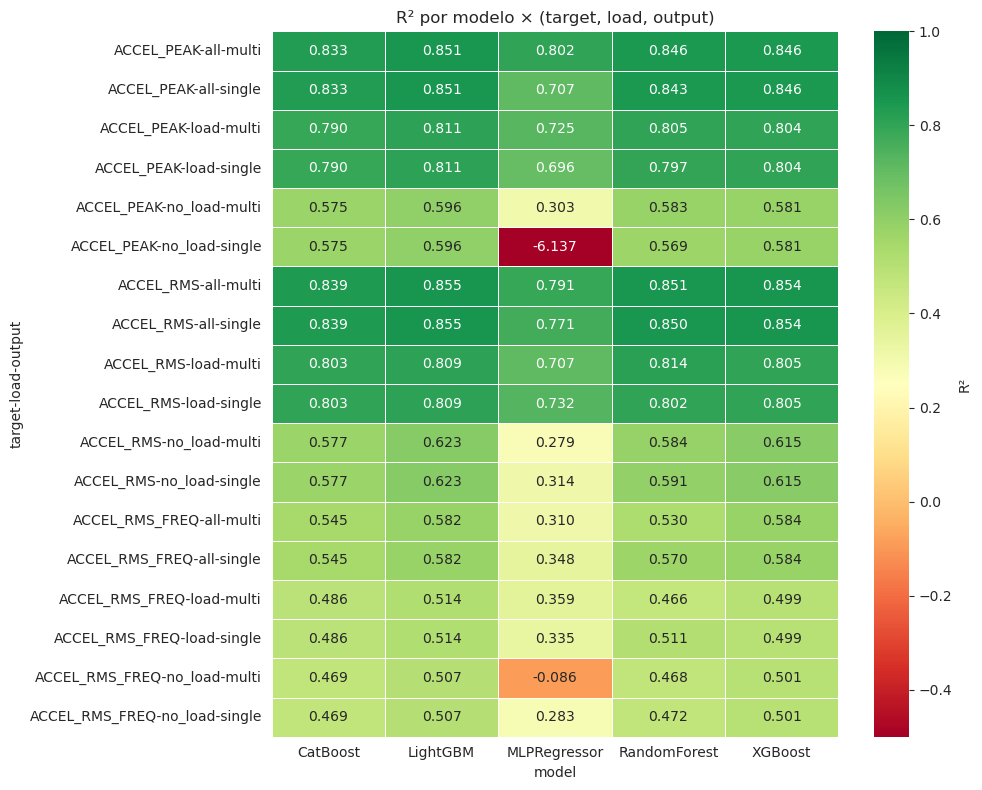

Guardado F1: <REPO_ROOT>/reports/figures/01_r2_heatmap.png


In [7]:
# F1 — Heatmap pivot R²
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    t4, annot=True, fmt='.3f', cmap='RdYlGn', vmin=-0.5, vmax=1.0,
    cbar_kws={'label': 'R²'}, linewidths=0.5, ax=ax,
)
ax.set_title('R² por modelo × (target, load, output)')
plt.tight_layout()
f1_path = FIGURES_DIR / '01_r2_heatmap.png'
plt.savefig(f1_path)
plt.show()
print(f'Guardado F1: {f1_path}')


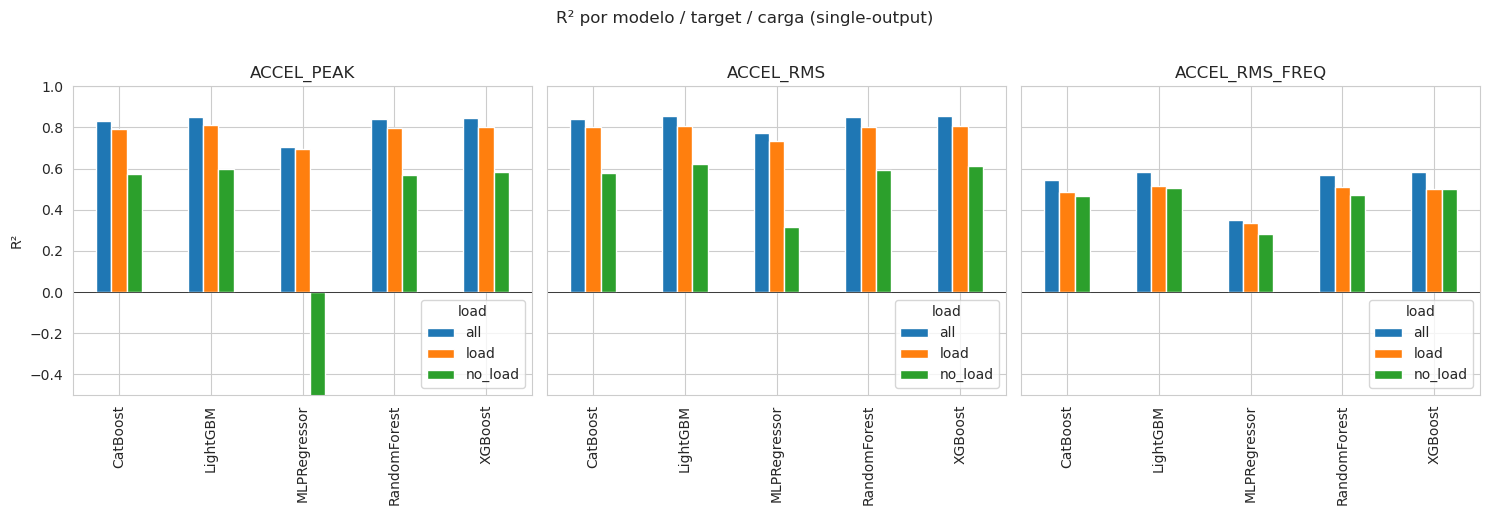

Guardado F2: <REPO_ROOT>/reports/figures/02_r2_bars_by_target.png


In [8]:
# F2 — Bar chart R² por modelo y target (3 sub-paneles por condición de carga)
targets = sorted(df['target'].unique())
loads_order = ['all', 'load', 'no_load']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, target in zip(axes, targets):
    sub = single[single['target'] == target]
    sub_pivot = sub.pivot(index='model', columns='load', values='R2')[loads_order]
    sub_pivot.plot(kind='bar', ax=ax)
    ax.set_title(target)
    ax.set_ylim(-0.5, 1.0)
    ax.set_ylabel('R²' if ax is axes[0] else '')
    ax.set_xlabel('')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(title='load', loc='lower right')
plt.suptitle('R² por modelo / target / carga (single-output)', y=1.02)
plt.tight_layout()
f2_path = FIGURES_DIR / '02_r2_bars_by_target.png'
plt.savefig(f2_path)
plt.show()
print(f'Guardado F2: {f2_path}')


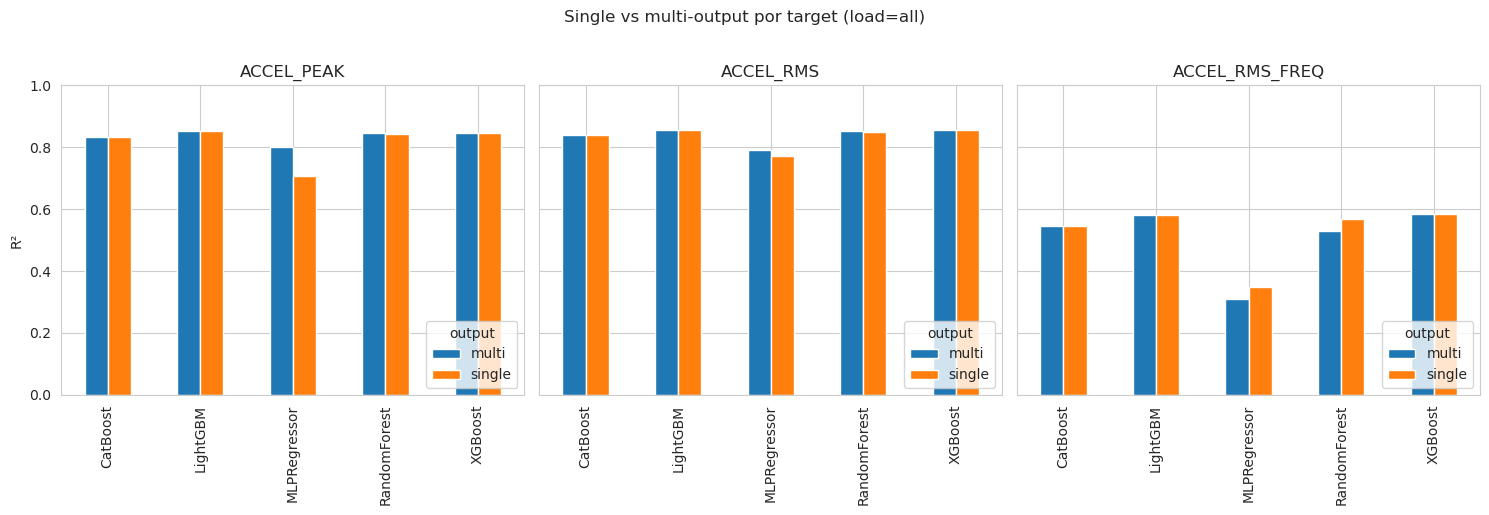

Guardado F3: <REPO_ROOT>/reports/figures/03_single_vs_multi.png


In [9]:
# F3 — Comparativa single vs multi-output (load='all', 3 sub-paneles por target)
all_df = df[df['load'] == 'all'].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, target in zip(axes, targets):
    sub = all_df[all_df['target'] == target]
    sub_pivot = sub.pivot(index='model', columns='output', values='R2')
    sub_pivot.plot(kind='bar', ax=ax)
    ax.set_title(target)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('R²' if ax is axes[0] else '')
    ax.set_xlabel('')
    ax.legend(title='output', loc='lower right')
plt.suptitle('Single vs multi-output por target (load=all)', y=1.02)
plt.tight_layout()
f3_path = FIGURES_DIR / '03_single_vs_multi.png'
plt.savefig(f3_path)
plt.show()
print(f'Guardado F3: {f3_path}')


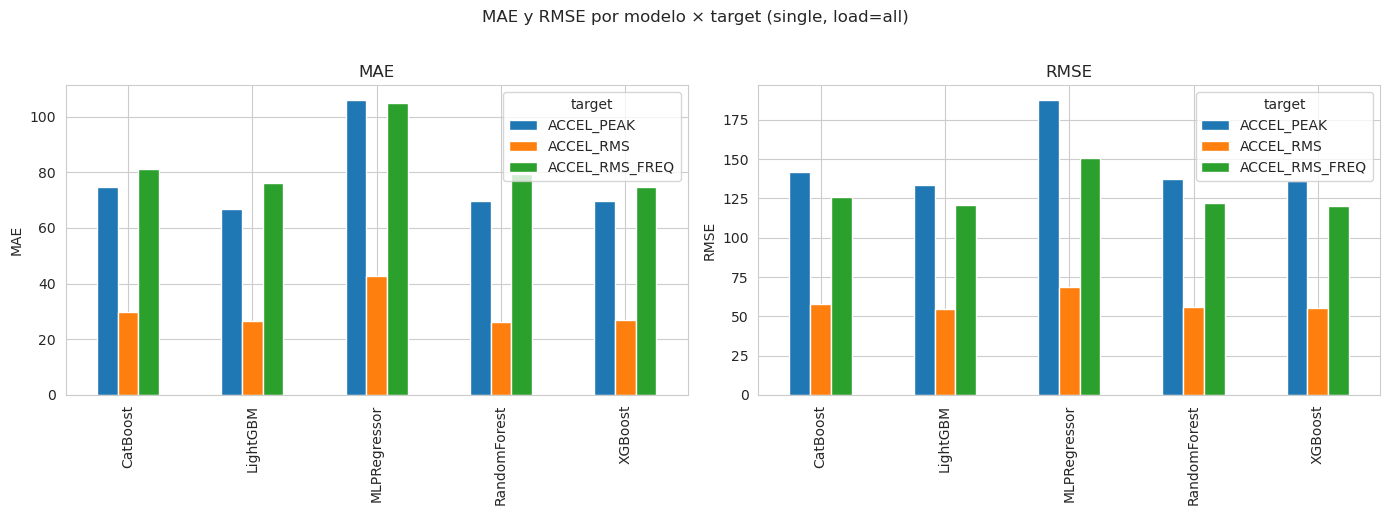

Guardado F4: <REPO_ROOT>/reports/figures/04_mae_rmse_by_target.png


In [10]:
# F4 — MAE y RMSE por modelo × target (single, load=all)
core = df[(df['output'] == 'single') & (df['load'] == 'all')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE']):
    sub_pivot = core.pivot(index='model', columns='target', values=metric)[targets]
    sub_pivot.plot(kind='bar', ax=ax)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.legend(title='target', loc='upper right')
plt.suptitle('MAE y RMSE por modelo × target (single, load=all)', y=1.02)
plt.tight_layout()
f4_path = FIGURES_DIR / '04_mae_rmse_by_target.png'
plt.savefig(f4_path)
plt.show()
print(f'Guardado F4: {f4_path}')


## 4. Figuras opcionales (F5–F6) — decisión durante ejecución

Criterios del plan §2:

- **F5 (fit_s informativo)**: se incluye si la suma de tiempos por modelo varía
  en > 5× entre el más rápido y el más lento, y la sección 5 del proyecto
  discute trade-off precisión/tiempo. Ratio observado en los datos: máximo /
  mínimo de ``fit_s_total`` por modelo.
- **F6 (distribución R²)**: se incluye si los R² por modelo separan visualmente
  (algunos modelos tienen R² consistentes, otros con outliers negativos).

Las dos decisiones se documentan en stdout antes de generar la figura.

In [11]:
# Decisión F5
ratio_fit = t5['fit_s_total'].max() / t5['fit_s_total'].min()
print(f'Ratio máx/mín fit_s_total entre modelos: {ratio_fit:.1f}×')
include_f5 = ratio_fit > 5.0
print(f'Criterio F5 (>5×): {"se incluye" if include_f5 else "se descarta"}')

# Decisión F6
r2_range = df.groupby('model')['R2'].agg(['min', 'max'])
spread = (r2_range['max'] - r2_range['min']).max()
print(f'Rango R² máximo dentro de un modelo: {spread:.3f}')
include_f6 = spread > 1.0  # spread amplio → distribución informativa
print(f'Criterio F6 (spread>1.0): {"se incluye" if include_f6 else "se descarta"}')


Ratio máx/mín fit_s_total entre modelos: 19.1×
Criterio F5 (>5×): se incluye
Rango R² máximo dentro de un modelo: 6.939
Criterio F6 (spread>1.0): se incluye


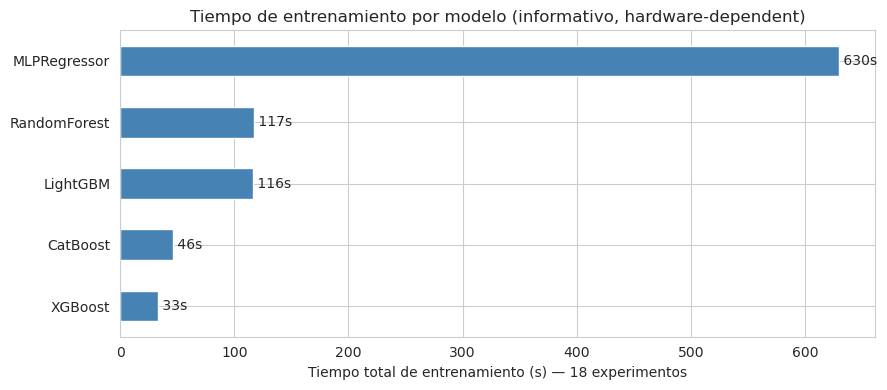

Guardado F5: <REPO_ROOT>/reports/figures/05_fit_times.png


In [12]:
# F5 — fit_s informativo por modelo (barras horizontales)
if include_f5:
    fig, ax = plt.subplots(figsize=(9, 4))
    t5['fit_s_total'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Tiempo total de entrenamiento (s) — 18 experimentos')
    ax.set_ylabel('')
    ax.set_title('Tiempo de entrenamiento por modelo (informativo, hardware-dependent)')
    for i, v in enumerate(t5['fit_s_total']):
        ax.text(v, i, f' {v:.0f}s', va='center')
    plt.tight_layout()
    f5_path = FIGURES_DIR / '05_fit_times.png'
    plt.savefig(f5_path)
    plt.show()
    print(f'Guardado F5: {f5_path}')
else:
    print('F5 descartada por criterio.')


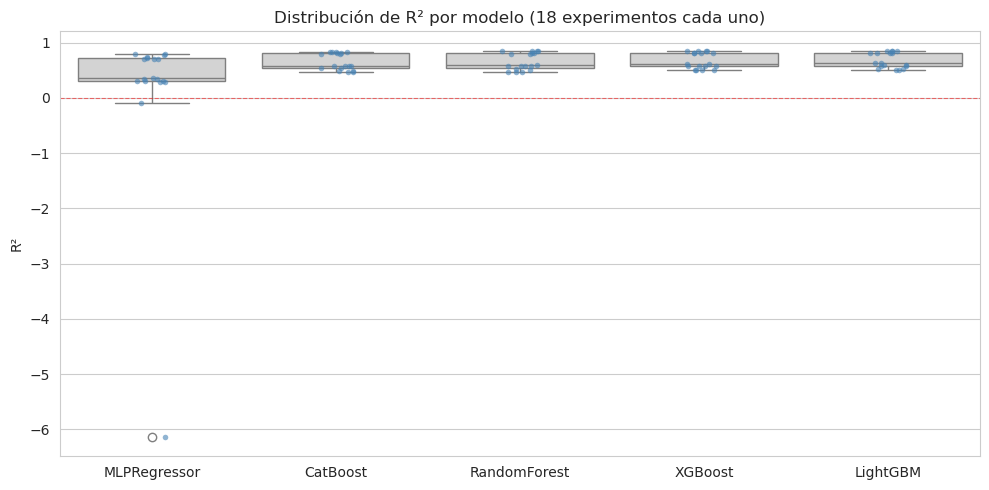

Guardado F6: <REPO_ROOT>/reports/figures/06_r2_distribution.png


In [13]:
# F6 — Distribución de R² por modelo (boxplot + stripplot)
if include_f6:
    fig, ax = plt.subplots(figsize=(10, 5))
    order = df.groupby('model')['R2'].median().sort_values().index.tolist()
    sns.boxplot(data=df, x='model', y='R2', order=order, ax=ax, color='lightgray')
    sns.stripplot(data=df, x='model', y='R2', order=order, ax=ax,
                  alpha=0.6, jitter=True, color='steelblue', size=4)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title('Distribución de R² por modelo (18 experimentos cada uno)')
    ax.set_ylabel('R²')
    ax.set_xlabel('')
    plt.tight_layout()
    f6_path = FIGURES_DIR / '06_r2_distribution.png'
    plt.savefig(f6_path)
    plt.show()
    print(f'Guardado F6: {f6_path}')
else:
    print('F6 descartada por criterio.')


## 5. Resumen final

In [14]:
# Resumen citable del proyecto
print('=' * 60)
print('  RESUMEN — Generación de figuras y tablas del proyecto')
print('=' * 60)
print(f'Tablas en {RESULTS_DIR}/: 5 (T1–T5)')
n_figs = 4 + int(include_f5) + int(include_f6)
print(f'Figuras en {FIGURES_DIR}/: {n_figs} (F1–F4 obligatorias + F5/F6 según criterio)')
print()
print('Mejor R² overall:')
best = df.nlargest(1, 'R2').iloc[0]
print(f'  modelo: {best["model"]}  output: {best["output"]}  target: {best["target"]}  load: {best["load"]}')
print(f'  R²={best["R2"]:.4f}  MAE={best["MAE"]:.4f}  RMSE={best["RMSE"]:.4f}')
print()
print('Mejor modelo por target (single, load=all):')
for t in targets:
    sub = single[(single['target'] == t) & (single['load'] == 'all')].sort_values('R2', ascending=False)
    if len(sub):
        b = sub.iloc[0]
        print(f'  {t:18s}  {b["model"]:14s}  R²={b["R2"]:.4f}  MAE={b["MAE"]:.4f}  RMSE={b["RMSE"]:.4f}')


  RESUMEN — Generación de figuras y tablas del proyecto
Tablas en <REPO_ROOT>/reports/results/: 5 (T1–T5)
Figuras en <REPO_ROOT>/reports/figures/: 6 (F1–F4 obligatorias + F5/F6 según criterio)

Mejor R² overall:
  modelo: LightGBM  output: single  target: ACCEL_RMS  load: all
  R²=0.8547  MAE=26.5000  RMSE=54.9610

Mejor modelo por target (single, load=all):
  ACCEL_PEAK          LightGBM        R²=0.8513  MAE=66.6130  RMSE=133.6960
  ACCEL_RMS           LightGBM        R²=0.8547  MAE=26.5000  RMSE=54.9610
  ACCEL_RMS_FREQ      XGBoost         R²=0.5838  MAE=74.8380  RMSE=120.2220
